# Assignment 1 Task 3

### Imports

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from scipy.signal import butter, freqz, lfilter
from numpy.lib.stride_tricks import sliding_window_view

In [25]:
data = sio.loadmat('Signals_task3/Signal3.mat')
r = data['R'].flatten()

fs = 44100
fc = 10000
Nsc = 128
Ncp = 20
Tsym = 0.058

### Demodulation

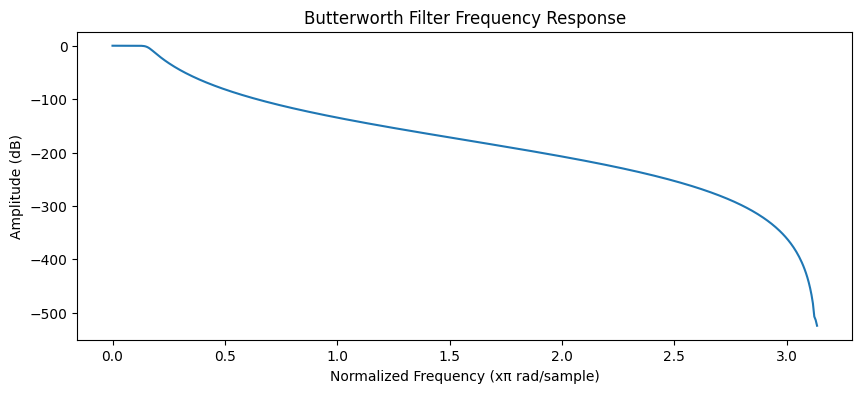

In [26]:
n = np.arange(len(r))
r_I =  2 * r * np.cos(2 * np.pi * fc * n / fs)
r_Q = -2 * r * np.sin(2 * np.pi * fc * n / fs)

b, a = butter(8, 0.05)
r_I_filt = lfilter(b, a, r_I)
r_Q_filt = lfilter(b, a, r_Q)

#Plot amplitude frequency response of filter
w, h = freqz(b, a)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Butterworth Filter Frequency Response')
plt.xlabel('Normalized Frequency (xπ rad/sample)')
plt.ylabel('Amplitude (dB)')
plt.grid()
plt.show()

## AD conversion and down sampling

In [27]:
# One useful OFDM symbol has Nsc = 128 samples and lasts 58 ms.
# Therefore the transmitter has interpolated the discrete-time OFDM signal by about 20.
D = int(round(fs * Tsym / Nsc))
r_I_down = r_I_filt[::D]
r_Q_down = r_Q_filt[::D]

# Form the complex baseband signal and downsample it back to the OFDM sampling rate.
r_bb = r_I_down + 1j * r_Q_down

print(f"D={D}, r_bb length = {len(r_bb)}, approx. {len(r_bb) // (Nsc+Ncp)} OFDM symbols")


D=20, r_bb length = 6353, approx. 42 OFDM symbols


## Synchronization and Removal of the Cyclic Prefix

In [ ]:
Nofdm = Nsc + Ncp  # 148 samples per OFDM symbol

wins  = sliding_window_view(r_bb, Nofdm)
gamma = np.sum(wins[:, :Ncp] * np.conj(wins[:, Nsc:Nsc+Ncp]), axis=1)
phi   = np.sum(np.abs(wins[:, Nsc:Nsc+Ncp])**2, axis=1)
mu    = np.abs(gamma) / (phi + 1e-10)

tau_ofdm = np.argmax(mu)
t0 = tau_ofdm % Nofdm   # first OFDM symbol starts here
print(f'OFDM symbol start offset: t0 = {t0}')

# Extract all complete OFDM symbols and remove CP
n_sym = (len(r_bb) - t0) // Nofdm
ofdm_blocks = r_bb[t0 : t0 + n_sym*Nofdm].reshape(n_sym, Nofdm)
ofdm_data   = ofdm_blocks[:, Ncp:]  # remove CP: keep last Nsc samples
print(f'Total OFDM symbols: {n_sym}')
